In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Dataset

New dataset that includes newly created variables:
- **New minority quintiles:**
    - Black Quintile (1 - highest black percentage, 5 - lowest black percentage)
    - Black, Native, other Quintile (non-white non-asian population: black of african american, american indiain or alaska native, native hawaiian or pacicfic islander, other race, two or more races)
- **New continuous variables for city fixed effects:**
    - Median income in the zip (divided by 10k)
    - Share of population with bachelor or higher degree
- **Other variables as previously:**
    - Income Quintiles (1 - lowest median income, 5 - highest median income )
    - Education Quintiles (1 - lowest percent bachelor education or higher, 5 - highest percent bachelor education or higher )


### Loading the dataset

In [41]:
cols = [
    "income_quintile",
    "minority_quintile",
    "education_quintile",
    "black_quintile",
    "black_native_other_quintile"
]

dtype_map = {c: "Int8" for c in cols}   # nullable integer type

df = pd.read_csv("new_merged_aggregated.csv", index_col=0, dtype=dtype_map)

# df = pd.read_csv(
#     "new_merged_aggregated.csv",
#     index_col=0,
#     dtype=dtype_map
# )

In [43]:
ai_adopt_df = pd.read_excel("ai_adoption.xlsx")
ai_adopt_df = ai_adopt_df[['Company', 'Fintech?']]
ai_adopt_df.head()

,Company,Fintech?
0,"EQUIFAX, INC.",credit bureat
1,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",credit bureat
2,Experian Information Solutions Inc.,credit bureat
3,"BANK OF AMERICA, NATIONAL ASSOCIATION",non fintech
4,WELLS FARGO & COMPANY,non fintech


In [44]:
mask = (
    (ai_adopt_df.index < 100) | 
    ((ai_adopt_df.index >= 100) & (ai_adopt_df['Fintech?'] == 'fintech'))
)
filtered_ai_adopt_df = ai_adopt_df[mask].copy()

In [45]:
# Keep only relevant categories
filtered_ai_adopt_df = filtered_ai_adopt_df[
    filtered_ai_adopt_df['Fintech?'].isin(['non fintech', 'fintech'])
]

In [46]:
# Report statistics
print(f"Total companies: {len(filtered_ai_adopt_df)}")
print(f"Fintechs: {(filtered_ai_adopt_df['Fintech?'] == 'fintech').sum()}")
print(f"Non-Fintechs: {(filtered_ai_adopt_df['Fintech?'] == 'non fintech').sum()}")

Total companies: 108
Fintechs: 26
Non-Fintechs: 82


In [47]:
# Create binary fintech indicator
filtered_ai_adopt_df['Fintech'] = (
    filtered_ai_adopt_df['Fintech?'].str.lower() == 'fintech'
).astype(int)

In [48]:
# Merge datasets using case-insensitive matching
merged_df = df.merge(
    filtered_ai_adopt_df[['Company', 'Fintech']],
    left_on=df['Company'].str.lower(),
    right_on=filtered_ai_adopt_df['Company'].str.lower(),
    how='left',
    suffixes=('', '_right')
).drop(columns=['key_0', 'Company_right'], errors='ignore')

### Dropping rows with companies that we didn't classify and any rows with blank demographic data

In [51]:
print(f'Records before dropna: {len(merged_df)}')
merged_df = merged_df.dropna()
print(f'Records after dropna: {len(merged_df)}')

Records before dropna: 2369594
Records after dropna: 1701381


In [50]:
merged_df.columns

Index(['ZIP code', 'month', 'Company', 'num_complaints', 'income_quintile',
       'minority_quintile', 'education_quintile', 'population_total',
       'income_zip_10k', 'share_bach_or_higher_zip', 'black_quintile',
       'black_native_other_quintile', 'Fintech'],
      dtype='object')

### Dummy variables

Dropping the first one to have as baseline

In [53]:
cols_to_encode = [
    'income_quintile', 'minority_quintile', 'education_quintile', 
    'Fintech', 'black_quintile', 'black_native_other_quintile'
]


merged_df = pd.get_dummies(
    merged_df, 
    columns=cols_to_encode, 
    drop_first=True
)

merged_df.head()

,ZIP code,month,Company,num_complaints,population_total,income_zip_10k,share_bach_or_higher_zip,income_quintile_2,income_quintile_3,income_quintile_4,income_quintile_5,minority_quintile_2,minority_quintile_3,minority_quintile_4,minority_quintile_5,education_quintile_2,education_quintile_3,education_quintile_4,education_quintile_5,Fintech_1.0,black_quintile_2,black_quintile_3,black_quintile_4,black_quintile_5,black_native_other_quintile_2,black_native_other_quintile_3,black_native_other_quintile_4,black_native_other_quintile_5
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
1,60620,2025-01,"Early Warning Services, LLC",87,66514.0,3.9499,0.182574,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False
2,33071,2012-06,Ocwen Financial Corporation,74,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
3,60629,2025-01,"Early Warning Services, LLC",66,114453.0,4.3372,0.110897,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
4,60628,2025-01,"Block, Inc.",61,62832.0,4.4410,0.216936,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False


### Number of complaints normalization (population)

Mimicking normalization from previous modelling: 
- by population total by zip-code (per 1000 inhabitants), 
- log transformation

In [52]:
merged_df['norm_num_complaints'] = (merged_df['num_complaints'] / merged_df['population_total']) * 1000

In [53]:
print("pre normalization\n",merged_df['num_complaints'].describe())
print("post normalization\n",merged_df['norm_num_complaints'].describe())

pre normalization
 count    1.701381e+06
mean     1.145770e+00
std      6.852932e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.960000e+02
Name: num_complaints, dtype: float64
post normalization
 count    1.701381e+06
mean     5.606848e-02
std      5.796299e-01
min      7.393387e-03
25%      2.122331e-02
50%      3.000300e-02
75%      4.456527e-02
max      2.500000e+02
Name: norm_num_complaints, dtype: float64


In [54]:
merged_df['log_norm_num_complaints'] = np.log1p(merged_df['norm_num_complaints'])
merged_df['log_norm_num_complaints'].describe()

count    1.701381e+06
mean     4.746442e-02
std      8.710332e-02
min      7.366190e-03
25%      2.100123e-02
50%      2.956172e-02
75%      4.360079e-02
max      5.525453e+00
Name: log_norm_num_complaints, dtype: float64

## Modelling

### Preparation of the variables for modelling

Defining which quintiles to consider for each area:

In [55]:
Q_m = "black_native_other_quintile"  # Minority quintile
Q_i = "income_quintile"               # Income quintile
Q_e = "education_quintile"            # Education quintile

In [56]:
# Create continuous time trend variable
merged_df['month_dt'] = pd.to_datetime(merged_df['month'])
merged_df['time_trend'] = (merged_df['month_dt'].dt.year - merged_df['month_dt'].dt.year.min()) * 12 + \
                          (merged_df['month_dt'].dt.month - 1)

print(f"Time trend ranges from {merged_df['time_trend'].min()} to {merged_df['time_trend'].max()}")
print(f"Unique time periods: {merged_df['time_trend'].nunique()}")

Time trend ranges from 11 to 177
Unique time periods: 167


In [57]:
merged_df.head(5)

,ZIP code,month,Company,num_complaints,population_total,income_zip_10k,share_bach_or_higher_zip,income_quintile_2,income_quintile_3,income_quintile_4,income_quintile_5,minority_quintile_2,minority_quintile_3,minority_quintile_4,minority_quintile_5,education_quintile_2,education_quintile_3,education_quintile_4,education_quintile_5,Fintech_1.0,black_quintile_2,black_quintile_3,black_quintile_4,black_quintile_5,black_native_other_quintile_2,black_native_other_quintile_3,black_native_other_quintile_4,black_native_other_quintile_5,norm_num_complaints,log_norm_num_complaints,month_dt,time_trend
0,33071,2012-06,"BANK OF AMERICA, NATIONAL ASSOCIATION",196,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,4.896817,1.774413,2012-06-01,17
1,60620,2025-01,"Early Warning Services, LLC",87,66514.0,3.9499,0.182574,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,1.307995,0.836379,2025-01-01,168
2,33071,2012-06,Ocwen Financial Corporation,74,40026.0,9.0849,0.434671,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,1.848798,1.046897,2012-06-01,17
3,60629,2025-01,"Early Warning Services, LLC",66,114453.0,4.3372,0.110897,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,0.576656,0.455306,2025-01-01,168
4,60628,2025-01,"Block, Inc.",61,62832.0,4.4410,0.216936,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,0.970843,0.678461,2025-01-01,168


In [58]:
# Create interaction terms: Fintech × all minority quintile dummies
# Convert to numeric first to avoid the boolean warning
for i in range(2, 6):
    merged_df[f'fintech_x_qm_{i}'] = merged_df['Fintech_1.0'].astype(int) * merged_df[f'{Q_m}_{i}'].astype(int)

print("Interaction terms created:")
print([col for col in merged_df.columns if 'fintech_x_qm' in col])

Interaction terms created:
['fintech_x_qm_2', 'fintech_x_qm_3', 'fintech_x_qm_4', 'fintech_x_qm_5']


In [59]:
# Base components
base_controls = 'C(Company) + time_trend'

# Quintile dummies (using our defined variable names)
qm_dummies = ' + '.join([f'{Q_m}_{i}' for i in range(2, 6)])
qi_dummies = ' + '.join([f'{Q_i}_{i}' for i in range(2, 6)])
qe_dummies = ' + '.join([f'{Q_e}_{i}' for i in range(2, 6)])

# Fintech × Qm interactions
fintech_qm_interaction = ' + '.join([f'fintech_x_qm_{i}' for i in range(2, 6)])

# Continuous controls
continuous_controls = 'income_zip_10k + share_bach_or_higher_zip'

### Correlations

Cramer's V and Heatmap:

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Bias correction
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [63]:
qm_cols = [f"{Q_m}_{i}" for i in range(2, 6)]
qi_cols = [f"{Q_i}_{i}" for i in range(2, 6)]
qe_cols = [f"{Q_e}_{i}" for i in range(2, 6)]

all_dummy_cols = qm_cols + qi_cols + qe_cols

In [64]:
cramer_matrix = pd.DataFrame(
    np.zeros((len(all_dummy_cols), len(all_dummy_cols))),
    index=all_dummy_cols,
    columns=all_dummy_cols
)

for col1 in all_dummy_cols:
    for col2 in all_dummy_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(merged_df[col1], merged_df[col2])

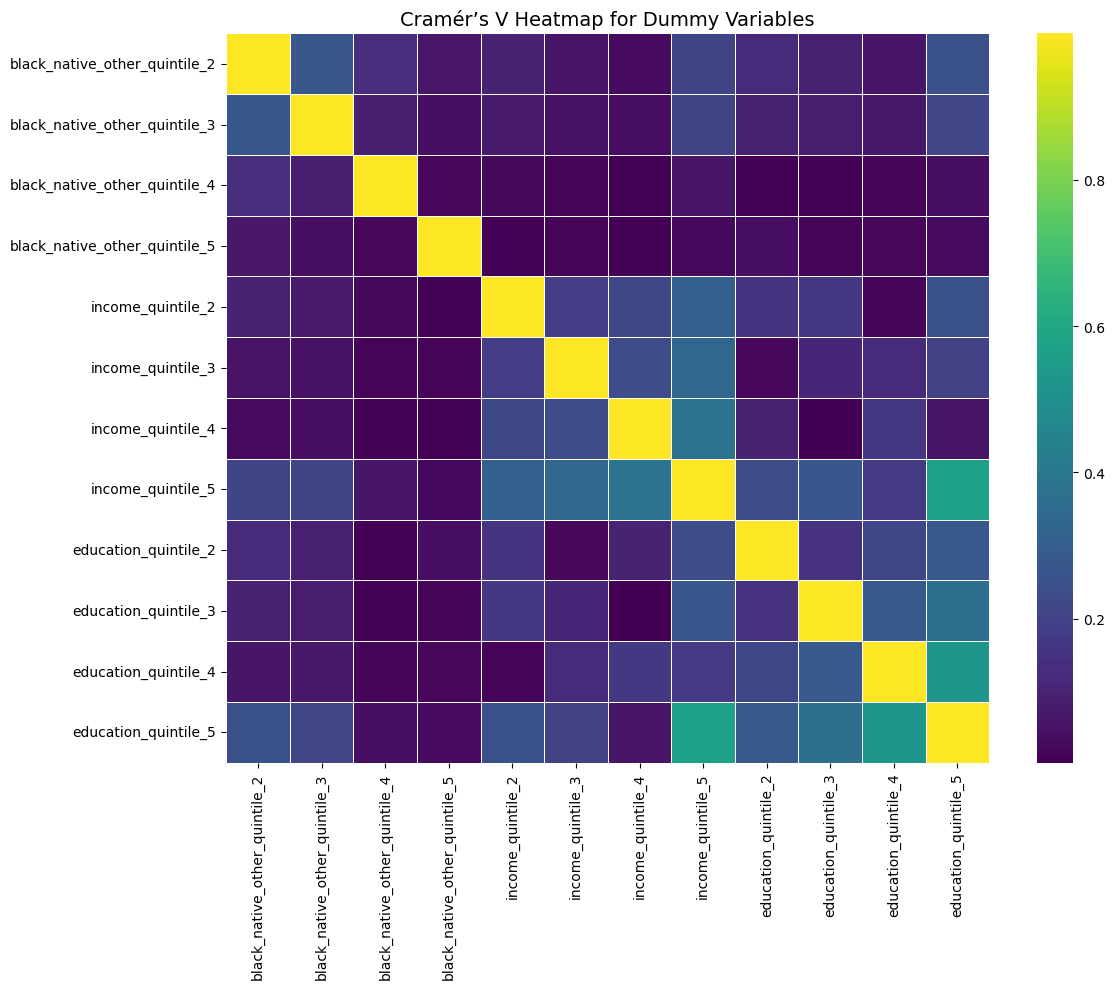

In [65]:
plt.figure(figsize=(12, 10))
sns.heatmap(cramer_matrix, annot=False, cmap="viridis", linewidths=0.5)
plt.title("Cramér’s V Heatmap for Dummy Variables", fontsize=14)
plt.tight_layout()
plt.show()

Highly correlated pairs of variables (threshold = 0.5):

In [68]:
threshold = 0.4

high_corr_pairs = []

for i in range(len(cramer_matrix.columns)):
    for j in range(i + 1, len(cramer_matrix.columns)):  # upper triangle only
        col1 = cramer_matrix.index[i]
        col2 = cramer_matrix.columns[j]
        value = cramer_matrix.iloc[i, j]

        if value > threshold:
            high_corr_pairs.append((col1, col2, value))

# Print results
print(f"Pairs with Cramér’s V > {threshold}:\n")
for col1, col2, val in high_corr_pairs:
    print(f"{col1}  —  {col2}   :   {val:.3f}")


Pairs with Cramér’s V > 0.4:

income_quintile_5  —  education_quintile_5   :   0.573
education_quintile_4  —  education_quintile_5   :   0.527


**Cramér’s V Interpretation:**

- The **strongest association** is between the **highest income quintile and the highest education quintile**. 

    - This is expected: ZIP codes with very high income levels typically also have very high levels of educational attainment.

- The second-highest association is **within the higher education quintiles** themselves: education_quintile_4 and education_quintile_5. 
  
    - This reflects natural correlation between top education categories - ZIPs in Q5 are often similar to those in Q4.

The associations are **expected** and **reasonable for socioeconomic variables**. They indicate that high-income and high-education areas overlap substantially.


### Multicollinearity

In [72]:
Q_m = "black_native_other_quintile"
Q_i = "income_quintile"
Q_e = "education_quintile"

qm_cols = [f"{Q_m}_{i}" for i in range(2, 6)]
qi_cols = [f"{Q_i}_{i}" for i in range(2, 6)]
qe_cols = [f"{Q_e}_{i}" for i in range(2, 6)]

# continuous controls
continuous_cols = ["income_zip_10k", "share_bach_or_higher_zip"]

# Matrix for VIF
X = merged_df[qm_cols + qi_cols + qe_cols + continuous_cols]

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

/var/folders/z_/_fwllf5j5n570_9sjbckq9mc0000gn/T/ipykernel_43014/2651051476.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[bool_cols] = X[bool_cols].astype(int)


In [73]:
# Add constant
X = add_constant(X)

# VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])]

print(vif_df)

                         variable        VIF
0                           const  30.777705
1   black_native_other_quintile_2   1.355210
2   black_native_other_quintile_3   1.335097
3   black_native_other_quintile_4   1.076615
4   black_native_other_quintile_5   1.013599
5               income_quintile_2   2.103968
6               income_quintile_3   2.689733
7               income_quintile_4   3.990498
8               income_quintile_5   9.302161
9            education_quintile_2   3.083271
10           education_quintile_3   4.578815
11           education_quintile_4   8.038132
12           education_quintile_5  15.420623
13                 income_zip_10k   5.646629
14       share_bach_or_higher_zip   6.642287


**VIF Interpretation:**

- Most VIF values are below the critical threshold = 10.
- **Race quintile dummies** show very low VIFs, meaning they are not strongly collinear with income or education controls. Their **coefficients should be estimated with high precision**.
- **Income quintile dummies** show mild to moderate multicollinearity. The highest income quintile is the most collinear, having strong association with high education areas.
- **Education quintile dummies** show higher VIFs. The highest education quintile is the most collinear variable in the model, driven by overlap with high income and high education ZIP characteristics. This may **inflate its standard errors**.
- **Continuous controls** show moderate multicollinearity, typical for socioeconomic variables. Their inclusion is still valuable for reducing omitted variable bias.

The model is **identifiable** and not threatened by multicollinearity. Some coefficients (especially education_quintile_5) will have **inflated standard errors**, but this is expected in socioeconomic regressions. 

Therefore, we will **keep all controls, to reduce the risk of omitted variable bias**.


### Model definitions

In [ ]:
# Model Family 1: Minority quintile dummies (Qm)
model_1a = f'log_norm_num_complaints ~ {qm_dummies} + {base_controls}'
model_1b = f'log_norm_num_complaints ~ {qm_dummies} + {fintech_qm_interaction} + {base_controls}'
model_1c = f'log_norm_num_complaints ~ {qm_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

# Model Family 2: Income quintile dummies (Qi)
model_2a = f'log_norm_num_complaints ~ {qi_dummies} + {base_controls}'
model_2b = f'log_norm_num_complaints ~ {qi_dummies} + {fintech_qm_interaction} + {base_controls}'
model_2c = f'log_norm_num_complaints ~ {qi_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

# Model Family 3: Education quintile dummies (Qe)
model_3a = f'log_norm_num_complaints ~ {qe_dummies} + {base_controls}'
model_3b = f'log_norm_num_complaints ~ {qe_dummies} + {fintech_qm_interaction} + {base_controls}'
model_3c = f'log_norm_num_complaints ~ {qe_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

# Model Family 4: All quintile dummies (Qm + Qi + Qe)
model_4a = f'log_norm_num_complaints ~ {qm_dummies} + {qi_dummies} + {qe_dummies} + {base_controls}'
model_4b = f'log_norm_num_complaints ~ {qm_dummies} + {qi_dummies} + {qe_dummies} + {fintech_qm_interaction} + {base_controls}'
model_4c = f'log_norm_num_complaints ~ {qm_dummies} + {qi_dummies} + {qe_dummies} + {fintech_qm_interaction} + {continuous_controls} + {base_controls}'

### Run all models

In [ ]:
# Dictionary to store results
results = {}

# Model specifications
model_specs = {
    '1a': model_1a, '1b': model_1b, '1c': model_1c,
    '2a': model_2a, '2b': model_2b, '2c': model_2c,
    '3a': model_3a, '3b': model_3b, '3c': model_3c,
    '4a': model_4a, '4b': model_4b, '4c': model_4c
}

# Run each model with clustered standard errors at Company level
print("Running regressions...\n")
for name, formula in model_specs.items():
    print(f"Model {name}...", end=' ')
    try:
        model = smf.ols(formula=formula, data=merged_df)
        # Fit with clustered standard errors at Company level
        result = model.fit(cov_type='cluster', cov_kwds={'groups': merged_df['Company']})
        results[name] = result
        print(f"✓ (N={result.nobs:,}, R²={result.rsquared:.4f})")
    except Exception as e:
        print(f"✗ FAILED: {str(e)}")

print(f"\n{'='*60}")
print(f"Completed {len(results)}/12 models successfully")
print(f"{'='*60}")

Running regressions...

Model 1a... ✓ (N=1,701,381.0, R²=0.1096)
Model 1b... ✓ (N=1,701,381.0, R²=0.1099)
Model 1c... ✓ (N=1,701,381.0, R²=0.1235)
Model 2a... ✓ (N=1,701,381.0, R²=0.0113)
Model 2b... ✓ (N=1,701,381.0, R²=0.0195)
Model 2c... ✓ (N=1,701,381.0, R²=0.0236)
Model 3a... ✓ (N=1,701,381.0, R²=0.0250)
Model 3b... ✓ (N=1,701,381.0, R²=0.0330)
Model 3c... ✓ (N=1,701,381.0, R²=0.0331)
Model 4a... ✓ (N=1,701,381.0, R²=0.1342)
Model 4b... ✓ (N=1,701,381.0, R²=0.1345)
Model 4c... ✓ (N=1,701,381.0, R²=0.1346)

Completed 12/12 models successfully


### Helper function definition
Defining a function to print results except for the coefficients for each of the company fixed effects

In [ ]:
def remove_company_rows(smry, prefix="C(Company)"):
    """
    Remove coefficient and standard error rows from a summary_col() Summary object where the row label starts with a given prefix.
    
    """
    tbl = smry.tables[0]  # pandas DataFrame

    idx = tbl.index.tolist()
    to_drop = []

    i = 0
    while i < len(idx):
        label = idx[i]
        if isinstance(label, str) and label.startswith(prefix):
            to_drop.append(label)   # drop this coefficient row
            # Also drop the row below if it is the SE row
            if i + 1 < len(idx) and idx[i + 1] == "":
                to_drop.append(idx[i + 1])
            i += 2
        else:
            i += 1

    # Apply the filtered table back to the summary object
    smry.tables[0] = tbl.drop(index=to_drop)

    return smry


### Model 1: Minority Results

In [ ]:
print("MODEL FAMILY 1: Minority Quintile Dummies (Qm)")
print("="*70)

smry = summary_col(
    [results['1a'], results['1b'], results['1c']],
    stars=True,
    float_format='%.4f',
    model_names=['(1a)', '(1b)', '(1c)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.4f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.4f}",
    }
)

# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 1: Minority Quintile Dummies (Qm)


,(1a),(1b),(1c)
Intercept,0.0407***,0.0428***,0.0611***
black_native_other_quintile_2[T.True],0.0052***,0.0058***,0.0157***
black_native_other_quintile_3[T.True],0.0203***,0.0214***,0.0345***
black_native_other_quintile_4[T.True],0.0770***,0.0791***,0.0871***
black_native_other_quintile_5[T.True],0.2544***,0.2563***,0.2562***
time_trend,-0.0000***,-0.0000***,-0.0000***
fintech_x_qm_2,,-0.0043**,-0.0040**
fintech_x_qm_3,,-0.0087***,-0.0082***
fintech_x_qm_4,,-0.0191***,-0.0187***
fintech_x_qm_5,,-0.0192**,-0.0197**


1. Stable influence across **minority quintiles**

    For non-fintechs:

   - Complaint frequency increases as the share of minority in a ZIP code decreases.

1. Coefficients are very **stable across models**

    - The minority complaint increase in coefficients across different quantiles is relatively stable and the estimates don't change significantly when adding additional variables or controls.

2. **The minority effect**

    For non-fintechs:

   - ZIPs in the lowest minority quintile have ~28–29% more complaints than ZIPs in the highest quintile, holding all else equal.

1. **Time trend** is very small

    - Over this long panel, complaints show a small but statistically significant **downward trend** over time.

2. Interaction terms are consistently **negative**

    - **Fintech** firms have relatively **fewer complaints** compared to non-fintech firms across all quintiles - the interaction term decreases the total effect of minorities on the number of complaints.

3. Adding **continuous socioeconomic controls** (1c) increases the Qm coefficients and the adjusted R^2.

#### Plot

Reference to:

**Paper:** Consumer-lending discrimination in the FinTech Era

**Authors:** Bartlett et al.

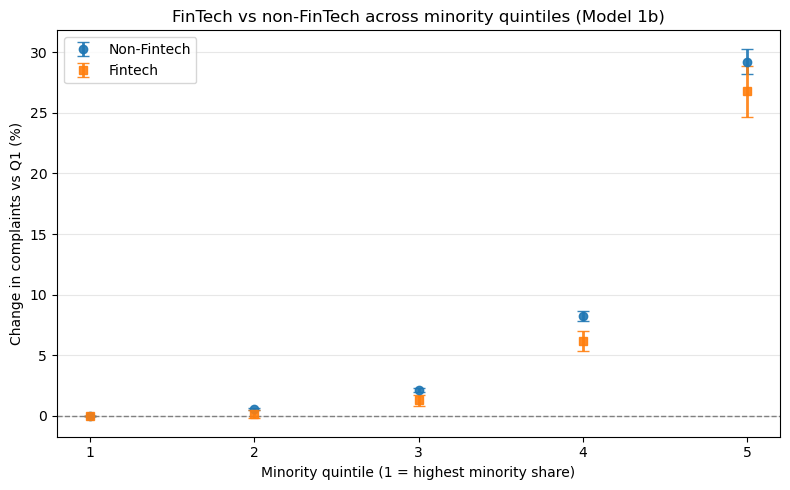

In [94]:
# ===========================
# Figure: FinTech vs non-FinTech by minority quintile
# (analogous to Bartlett et al. Fig. 5a)
# ===========================

res = results['1b']      # use model 1b (Qm dummies + fintech interactions + controls)

quintiles = [1, 2, 3, 4, 5]
rows = []

cov = res.cov_params()

for q in quintiles:
    if q == 1:
        # base group: highest minority quintile (omitted category)
        for t in ['Non-Fintech', 'Fintech']:
            rows.append({
                'quintile': q,
                'type': t,
                'beta': 0.0,
                'se': 0.0
            })
    else:
        base_name = f'{Q_m}_{q}[T.True]'  # e.g. "black_native_other_quintile_2[T.True]"
        int_name  = f'fintech_x_qm_{q}'   # interaction term

        # --- Non-Fintech effect (only main dummy) ---
        beta_nf = res.params[base_name]
        se_nf   = res.bse[base_name]
        rows.append({
            'quintile': q,
            'type': 'Non-Fintech',
            'beta': beta_nf,
            'se': se_nf
        })

        # --- Fintech effect (main + interaction) ---
        beta_ft = res.params[base_name] + res.params[int_name]
        var_ft  = (cov.loc[base_name, base_name] +
                   cov.loc[int_name, int_name] +
                   2 * cov.loc[base_name, int_name])
        se_ft   = np.sqrt(var_ft)

        rows.append({
            'quintile': q,
            'type': 'Fintech',
            'beta': beta_ft,
            'se': se_ft
        })

effects_df = pd.DataFrame(rows)

# transform log-coefficients into % change in complaints vs Q1
effects_df['effect_pct'] = (np.exp(effects_df['beta']) - 1) * 100
effects_df['ci_low']  = (np.exp(effects_df['beta'] - 1.96*effects_df['se']) - 1) * 100
effects_df['ci_high'] = (np.exp(effects_df['beta'] + 1.96*effects_df['se']) - 1) * 100

# distance from point estimate to CI bounds
effects_df['err_low']  = effects_df['effect_pct'] - effects_df['ci_low']
effects_df['err_high'] = effects_df['ci_high'] - effects_df['effect_pct']

# ----- Plot -----
fig, ax = plt.subplots(figsize=(8, 5))

for typ, marker in [('Non-Fintech', 'o'), ('Fintech', 's')]:
    sub = effects_df[effects_df['type'] == typ]
    ax.errorbar(
        sub['quintile'],
        sub['effect_pct'],
        yerr=[sub['err_low'], sub['err_high']],
        fmt=marker,
        capsize=4,
        linewidth=2,
        alpha=0.9,
        label=typ
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(quintiles)
ax.set_xlabel('Minority quintile (1 = highest minority share)')
ax.set_ylabel('Change in complaints vs Q1 (%)')
ax.set_title('FinTech vs non-FinTech across minority quintiles (Model 1b)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Across all quintiles, **fintech firms show fewer complaints than non-fintech firms**, indicating a relative complaint advantage. This advantage is **largest in the lowest-minority ZIPs**. In contrast, the advantage becomes **smaller in the highest-minority ZIPs**.

### Model 2: Income Results

In [ ]:
print("MODEL FAMILY 2: Income Quintile Dummies (Qi)")
print("="*70)

smry = summary_col(
    [results['2a'], results['2b'], results['2c']],
    stars=True,
    float_format='%.4f',
    model_names=['(2a)', '(2b)', '(2c)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.4f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.4f}",
    }
)

# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 2: Income Quintile Dummies (Qi)


,(2a),(2b),(2c)
Intercept,0.0675***,0.0627***,0.0615***
income_quintile_2[T.True],-0.0101***,-0.0105***,-0.0108***
income_quintile_3[T.True],-0.0150***,-0.0156***,-0.0158***
income_quintile_4[T.True],-0.0183***,-0.0190***,-0.0195***
income_quintile_5[T.True],-0.0208***,-0.0219***,-0.0223***
time_trend,-0.0001***,-0.0001***,-0.0001***
fintech_x_qm_2,,0.0069***,0.0092***
fintech_x_qm_3,,0.0185***,0.0209***
fintech_x_qm_4,,0.0646***,0.0644***
fintech_x_qm_5,,0.2381***,0.2361***


1. **Clear, monotonic pattern** across income quintiles   

    For both fintechs and non-fintechs:

    - Relative to the lowest-income ZIPs, each step up in the income distribution is associated with **fewer complaints**.  

2. Coefficients are **stable across specifications**  

3. Largest effect observed for the **highest-income quintile (Qi_5)**  

    For both fintechs and non-fintechs:

   - Firms in the highest-income ZIPs have roughly **2.0–2.3% fewer complaints** than those in the lowest income quintile, holding all else constant.  

4. Time trend remains **small and negative**  
   - Complaints show a **very small but statistically detectable downward trend** over time.

5. **CHANGE OF SIGN COMPARED TO MODEL 1:** Fintech × minority-quintile interactions are consistently positive 
    - Positive interaction coefficients mean **fintech** companies have **more complaints than non-fintechs**.

6. Adding continuous socioeconomic controls slightly **increases model fit**

### Model 3: Education Results

In [78]:
print("MODEL FAMILY 3: Education Quintile Dummies (Qe)")
print("="*70)

smry = summary_col(
    [results['3a'], results['3b'], results['3c']],
    stars=True,
    float_format='%.4f',
    model_names=['(3a)', '(3b)', '(3c)'],
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.4f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.4f}",
    }
)

# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 3: Education Quintile Dummies (Qe)


,(3a),(3b),(3c)
Intercept,0.0983***,0.0924***,0.0908***
education_quintile_2[T.True],-0.0286***,-0.0288***,-0.0291***
education_quintile_3[T.True],-0.0420***,-0.0422***,-0.0427***
education_quintile_4[T.True],-0.0515***,-0.0516***,-0.0525***
education_quintile_5[T.True],-0.0522***,-0.0530***,-0.0547***
time_trend,-0.0001***,-0.0001***,-0.0001***
fintech_x_qm_2,,0.0090***,0.0087***
fintech_x_qm_3,,0.0205***,0.0200***
fintech_x_qm_4,,0.0648***,0.0642***
fintech_x_qm_5,,0.2321***,0.2318***


1. **Strong, monotonic pattern across education quintiles**  
   
   For non-fintech and fintech companies:

    - Complaint frequency consistently **decreases as education levels rise**.

2. Coefficients are highly **stable across specifications**  

3. Largest effects observed for the **highest-education quintiles (Qe_4 and Qe_5)**  
   
   For non-fintech and fintech companies:

    - ZIPs in the highest education quintile (Qe_5) exhibit roughly **5.2–5.5% fewer complaints** than the lowest-education ZIPs (Qe_1), holding other factors constant. 
    - The relationship is strictly monotonic: **higher educational has fewer complaints** at every step.

4. Time trend remains **small and negative**  

5. **CHANGE OF SIGN COMPARED TO MODEL 1:** Fintech × minority-quintile interactions remain consistently positive  
    
    - Fintech companies have **more complaints relative to non-fintechs** in lower-minority ZIPs than in the highest-minority ZIPs. 

6. Adding continuous controls **increases model fit without altering education effects**  


### Model 4: All Demographics Results

In [79]:
print("MODEL FAMILY 4: All Quintile Dummies (Qm + Qi + Qe)")
print("="*70)

smry = summary_col([results['4a'], results['4b'], results['4c']], 
            stars=True,
            float_format='%.4f',
            model_names=['(4a)', '(4b)', '(4c)'],
            info_dict={'N':lambda x: f"{int(x.nobs):,}",
                      'R²':lambda x: f"{x.rsquared:.4f}",
                      'Adj. R²':lambda x: f"{x.rsquared_adj:.4f}"})
# Clean it
smry = remove_company_rows(smry)
smry

MODEL FAMILY 4: All Quintile Dummies (Qm + Qi + Qe)


,(4a),(4b),(4c)
Intercept,0.0883***,0.0901***,0.0916***
black_native_other_quintile_2[T.True],0.0162***,0.0167***,0.0170***
black_native_other_quintile_3[T.True],0.0323***,0.0333***,0.0340***
black_native_other_quintile_4[T.True],0.0854***,0.0873***,0.0876***
black_native_other_quintile_5[T.True],0.2525***,0.2545***,0.2545***
income_quintile_2[T.True],-0.0058***,-0.0057***,-0.0056***
income_quintile_3[T.True],-0.0084***,-0.0083***,-0.0080***
income_quintile_4[T.True],-0.0099***,-0.0099***,-0.0093***
income_quintile_5[T.True],-0.0133***,-0.0133***,-0.0116***
education_quintile_2[T.True],-0.0287***,-0.0287***,-0.0280***


1. All three socioeconomic effects remain **strong and monotonic**    

    For non-fintech and non-fintech companies:

   - **Higher-income ZIPs** file **fewer complaints** than the lowest-income ZIPs.  
   - **Higher-education ZIPs** file **fewer complaints** than the least-educated ZIPs.  

2. Coefficient magnitudes remain **stable across model specifications**   

3. **Minority-quintile effects remain the strongest among the three effects** 
    
    - **Minority composition** remains the single **strongest** predictor of complaint frequency even after fully accounting for income and education.


4. Fintech × minority interactions remain **consistently negative**  

    - **Fintech companies** have **fewer complaints** relative to non-fintechs in lower-minority ZIPs than in the highest-minority ZIPs.

5. Time trend is again extremely **small and negative**  

6. **Model fit improves meaningfully** in the joint model
   
    - Adjusted R² rises, substantially higher than any of the single-dimension models.

    - Minority, income, and education jointly explain substantially more variation in complaints than any one dimension alone.


#### Plot

Reference to:

**Paper:** Color and credit: Race, regulation, and the quality of financial services

**Authors:** Begley et al.

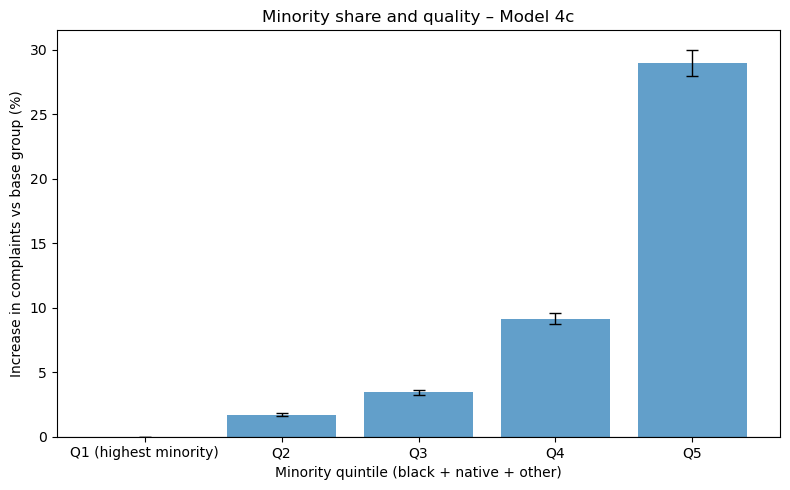

In [ ]:

result_4c = results['4c']          
base_var = Q_m                     

effects = []     # point estimates in %
lower_ci = []    # lower 95% CI in %
upper_ci = []    # upper 95% CI in %
labels = []      # x-axis labels

# Base group
labels.append("Q1 (highest minority)")
effects.append(0.0)
lower_ci.append(0.0)
upper_ci.append(0.0)

# Quintiles 2–5
conf_int = result_4c.conf_int()

for q in range(2, 6):
    var_name = f"{base_var}_{q}[T.True]"

    beta = result_4c.params[var_name]
    ci_low, ci_high = conf_int.loc[var_name]

    # Transform coefficient into % change
    # %Δ ≈ (exp(beta) - 1) * 100
    eff = (np.exp(beta) - 1) * 100
    lo = (np.exp(ci_low) - 1) * 100
    hi = (np.exp(ci_high) - 1) * 100

    labels.append(f"Q{q}")
    effects.append(eff)
    lower_ci.append(lo)
    upper_ci.append(hi)

effects = np.array(effects)
lower_ci = np.array(lower_ci)
upper_ci = np.array(upper_ci)

# Error bar sizes (distance from point estimate)
yerr = np.vstack([effects - lower_ci, upper_ci - effects])

# Plot mimicking the paper

x = np.arange(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(x, effects, alpha=0.7)
plt.errorbar(
    x,
    effects,
    yerr=yerr,
    fmt='none',
    ecolor='black',
    capsize=4,
    linewidth=1
)

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, labels)
plt.ylabel("Increase in complaints vs base group (%)")
plt.xlabel("Minority quintile (black + native + other)")
plt.title("Minority share vs number of complaints – Model 4c")

plt.tight_layout()
plt.show()


Under Model 4, we can see a **strong upward trend** in the number of complaints, relative to the base group - Q1 (high minority share). 

ZIP codes with higher-minority quintiles experience far fewer increases in complaints, whereas areas in lower-minority quintiles see higher increases.

### All 4 models compared

In [ ]:
print("ALL MODELS")
print("="*170)

smry = summary_col([results['1a'], results['1b'], results['1c'],results['2a'], results['2b'], results['2c'],
                    results['3a'], results['3b'], results['3c'],results['4a'], results['4b'], results['4c']], 
            stars=True,
            float_format='%.4f',
            model_names=['(1a)', '(1b)', '(1c)','(2a)', '(2b)', '(2c)','(3a)', '(3b)', '(3c)','(4a)', '(4b)', '(4c)'],
            info_dict={'N':lambda x: f"{int(x.nobs):,}",
                      'R²':lambda x: f"{x.rsquared:.4f}",
                      'Adj. R²':lambda x: f"{x.rsquared_adj:.4f}"})
# Clean it
smry = remove_company_rows(smry)
smry

ALL MODELS


,(1a),(1b),(1c),(2a),(2b),(2c),(3a),(3b),(3c),(4a),(4b),(4c)
Intercept,0.0407***,0.0428***,0.0611***,0.0675***,0.0627***,0.0615***,0.0983***,0.0924***,0.0908***,0.0883***,0.0901***,0.0916***
black_native_other_quintile_2[T.True],0.0052***,0.0058***,0.0157***,,,,,,,0.0162***,0.0167***,0.0170***
black_native_other_quintile_3[T.True],0.0203***,0.0214***,0.0345***,,,,,,,0.0323***,0.0333***,0.0340***
black_native_other_quintile_4[T.True],0.0770***,0.0791***,0.0871***,,,,,,,0.0854***,0.0873***,0.0876***
black_native_other_quintile_5[T.True],0.2544***,0.2563***,0.2562***,,,,,,,0.2525***,0.2545***,0.2545***
time_trend,-0.0000***,-0.0000***,-0.0000***,-0.0001***,-0.0001***,-0.0001***,-0.0001***,-0.0001***,-0.0001***,-0.0000***,-0.0000***,-0.0000***
fintech_x_qm_2,,-0.0043**,-0.0040**,,0.0069***,0.0092***,,0.0090***,0.0087***,,-0.0036**,-0.0035**
fintech_x_qm_3,,-0.0087***,-0.0082***,,0.0185***,0.0209***,,0.0205***,0.0200***,,-0.0079***,-0.0078***
fintech_x_qm_4,,-0.0191***,-0.0187***,,0.0646***,0.0644***,,0.0648***,0.0642***,,-0.0184***,-0.0184***
fintech_x_qm_5,,-0.0192**,-0.0197**,,0.2381***,0.2361***,,0.2321***,0.2318***,,-0.0198**,-0.0198**


The **interaction term** between fintechs and the minority quintile **changes the sign depending on the model specification**. 

This is due to the fact that leaving minority share out forces the income-only and education-only models to improperly attribute minority-related variation to other coefficients, leading to **omitted variable bias**. 

**Model 4 controls for all major demographic factors simultaneously**, what removes the distortions caused by omitted variables in the earlier models.

### Lincom - computing the **total effect of fintech vs. non-fintech companies** for each quintile

In [ ]:
def compute_total_effects(result, model_name):
    """Compute total effects for fintech vs non-fintech across quintiles."""
    import numpy as np
    
    # Map model to quintile variable
    quintile_map = {'1': 'black_native_other_quintile', '2': 'income_quintile', 
                    '3': 'education_quintile', '4': 'black_native_other_quintile'}
    quintile_var = quintile_map[model_name[0]]
    
    effects = []
    params, cov = result.params, result.cov_params()
    
    for q in range(2, 6):
        qvar = f'{quintile_var}_{q}[T.True]'
        intvar = f'fintech_x_qm_{q}'
        
        if qvar not in params.index:
            continue
        
        # Non-fintech (main effect only)
        main_eff, main_se = params[qvar], result.bse[qvar]
        effects.append({'Quintile': q, 'Type': 'Non-Fintech', 'Effect': main_eff, 
                       'SE': main_se, 'CI_lower': main_eff - 1.96*main_se, 
                       'CI_upper': main_eff + 1.96*main_se})
        
        # Fintech (main + interaction)
        if intvar in params.index:
            total_eff = params[qvar] + params[intvar]
            total_var = cov.loc[qvar, qvar] + cov.loc[intvar, intvar] + 2*cov.loc[qvar, intvar]
            total_se = np.sqrt(total_var)
            effects.append({'Quintile': q, 'Type': 'Fintech', 'Effect': total_eff,
                           'SE': total_se, 'CI_lower': total_eff - 1.96*total_se,
                           'CI_upper': total_eff + 1.96*total_se})
    
    return pd.DataFrame(effects)

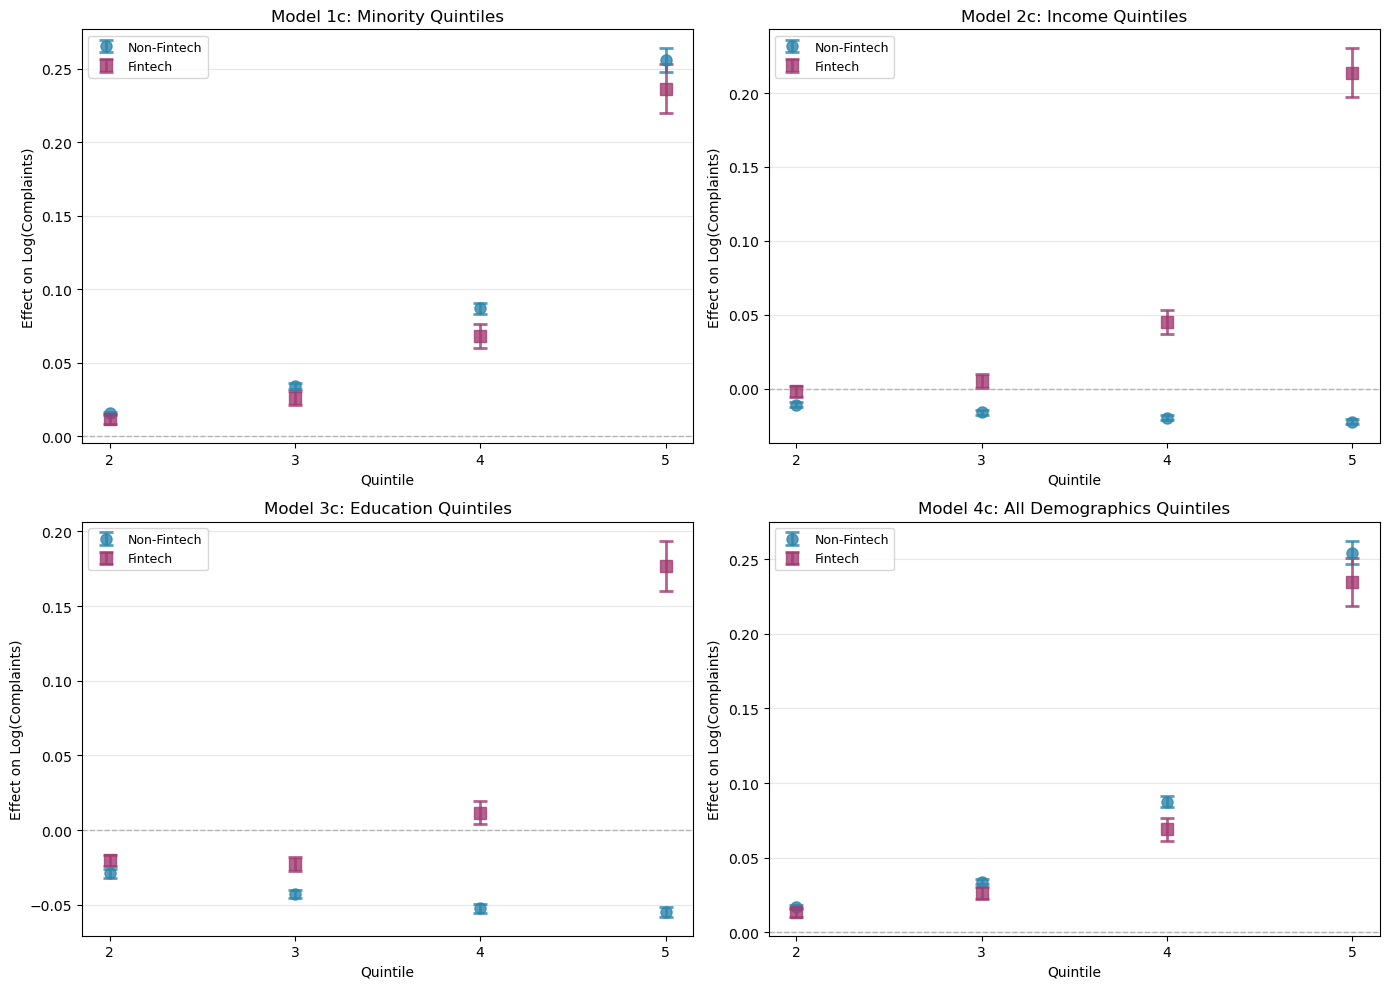


Model 4c: Combined Effects Summary
 Quintile        Type  Effect     SE  CI_lower  CI_upper
        2 Non-Fintech  0.0170 0.0006    0.0159    0.0181
        2     Fintech  0.0135 0.0016    0.0104    0.0165
        3 Non-Fintech  0.0340 0.0010    0.0321    0.0359
        3     Fintech  0.0262 0.0020    0.0223    0.0301
        4 Non-Fintech  0.0876 0.0020    0.0838    0.0915
        4     Fintech  0.0692 0.0039    0.0616    0.0769
        5 Non-Fintech  0.2545 0.0041    0.2465    0.2624
        5     Fintech  0.2346 0.0083    0.2184    0.2509


In [82]:
# Plotting
model_specs = [('1c', 'Minority'), ('2c', 'Income'), ('3c', 'Education'), ('4c', 'All Demographics')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for (model_name, label), ax in zip(model_specs, axes.flatten()):
    effects_df = compute_total_effects(results[model_name], model_name)
    
    if effects_df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
    else:
        for type_name, color, marker in [('Non-Fintech', '#2E86AB', 'o'), ('Fintech', '#A23B72', 's')]:
            subset = effects_df[effects_df['Type'] == type_name]
            if not subset.empty:
                ax.errorbar(subset['Quintile'], subset['Effect'], yerr=1.96*subset['SE'],
                           fmt=marker, color=color, label=type_name, markersize=8, 
                           capsize=5, capthick=2, linewidth=2, alpha=0.8)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set(xlabel='Quintile', ylabel='Effect on Log(Complaints)', 
           title=f'Model {model_name}: {label} Quintiles', xticks=[2, 3, 4, 5])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
effects_4c = compute_total_effects(results['4c'], '4c')
print("\nModel 4c: Combined Effects Summary\n" + "="*70)
print(effects_4c.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

We focus on the insights from **Model 4**, as it includes the **full set of variables and controls**, therefore minimizing the risk of omitted variables bias and providing the most reliable estimate of the relationship between minority share and complaint differentials (the variables of interest to answer our Research Question).

As shown in the graph, **fintech firms have fewer complaints** than non-fintech firms **across all minority-share quintiles**, indicating a consistent relative advantage. However, the magnitude of this advantage is not uniform. The gap is largest in ZIP codes with low minority shares, where fintech firms experience fewer complaints relative to their non-fintech counterparts. As the minority share increases, this advantage progressively diminishes, becoming much smaller in the highest-minority ZIP codes.

This pattern suggests that while fintech firms generally receive fewer complaints than non-fintech firms, their **relative performance weakens in areas with higher concentrations of minority residents.**

So do fintechs discriminate?

The results have shown that fintech firms have fewer complaints overall than non-fintech firms. However, their advantage shrinks substantially in high-minority ZIP codes. **Fintechs exhibit a weaker performance advantage in high-minority areas**, which is consistent with, but **does not prove, unequal service outcomes across demographic groups**. 

This pattern motivates **further investigation into whether structural, economic, or discriminatory mechanisms explain the disparit**y.